# BloodPressure.

## Exploratory data analysis Section:
    1. Data Quality check
    2. Univariate Analysis
    3. Bivariate Analysis
    4. Multi-variate Analysis
    5. Outlier Detection

### Import the libraries

In [54]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, pearsonr
import plotly.express as px
import polars as pl


sys.path.append(os.path.join(os.getcwd(), "Utils"))
# find the parent folder of "notebooks"
# add the utils folder to Python path
BASE_DIR = os.path.abspath("..")
sys.path.append(os.path.join(BASE_DIR, "utils"))


# import the RTL module

# the modules that I've Built.

from Melted import df_melt , Merge_df,correct_order_timeOfDay
from visualization import Plot_R, Plot_L, plot_Univariate_num
from StatMelt import Average_Melt, iqr_bounds
# from Melted import Make_dataframe

### Read and melt the dataset

- used pandas to first read the data
- Then I needed to do ffill because My Excel dataset had empty cells and pandas recognized it as NANs
- Melt dataset to have a good structure for My dataset 

In [55]:
df = pd.read_excel('../Data/BP.xlsx')
df.head()

,day,date,hand,type,morning,noon,night
0,1.0,1405/2/8,R,Systolic,NaN,NaN,NaN
1,NaN,NaN,NaN,Diastolic,NaN,NaN,NaN
2,NaN,NaN,NaN,Pulse,NaN,NaN,NaN
3,NaN,NaN,L,Systolic,149.0,140.0,138.0
4,NaN,NaN,NaN,Diastolic,89.0,74.0,69.0


#### Decompose the dataset into Left and Right Arm

first I need to make dimensional of the excel file more understandable to pandas libraries.

In [56]:
df['day'] = df['day'].ffill()
df['hand'] = df['hand'].ffill()
df['date'] = df['date'].ffill()

df.tail(10)

,day,date,hand,type,morning,noon,night
50,9.0,1405/2/16,R,Pulse,67.0,85.0,70.0
51,9.0,1405/2/16,L,Systolic,123.0,125.0,122.0
52,9.0,1405/2/16,L,Diastolic,70.0,71.0,84.0
53,9.0,1405/2/16,L,Pulse,68.0,80.0,74.0
54,10.0,1405/2/17,R,Systolic,132.0,114.0,116.0
55,10.0,1405/2/17,R,Diastolic,68.0,59.0,72.0
56,10.0,1405/2/17,R,Pulse,64.0,68.0,66.0
57,10.0,1405/2/17,L,Systolic,133.0,122.0,123.0
58,10.0,1405/2/17,L,Diastolic,73.0,63.0,70.0
59,10.0,1405/2/17,L,Pulse,66.0,68.0,67.0


- drop the NaN
- separating the categorical and numerical columns

In [57]:
df = df.dropna()
col_num = ['morning', 'noon', 'night']
col_cat = ['hand', 'type']

- filter the Right Hand

In [58]:
# filtering the right hand
df_R = df[df['hand'] == 'R']
df_R = df_R.drop('hand' , axis=1)
df_R_s = df_R[df_R['type'] == 'Systolic'] 
df_R_d =  df_R[df_R['type'] == 'Diastolic'] 
df_R_p =  df_R[df_R['type'] == 'Pulse']


df_R.head(10)

,day,date,type,morning,noon,night
18,4.0,1405/2/11,Systolic,133.0,137.0,133.0
19,4.0,1405/2/11,Diastolic,60.0,73.0,76.0
20,4.0,1405/2/11,Pulse,56.0,78.0,71.0
24,5.0,1405/2/12,Systolic,130.0,116.0,119.0
25,5.0,1405/2/12,Diastolic,75.0,58.0,68.0
26,5.0,1405/2/12,Pulse,59.0,66.0,64.0
30,6.0,1405/2/13,Systolic,121.0,128.0,121.0
31,6.0,1405/2/13,Diastolic,68.0,72.0,67.0
32,6.0,1405/2/13,Pulse,60.0,83.0,76.0
36,7.0,1405/2/14,Systolic,121.0,121.0,118.0


- filter the Left Hand

In [59]:
# filtering the left hand
df_L = df[df['hand'] == 'L']
df_L = df_L.drop('hand' , axis=1)
df_L_s = df_L[df_L['type'] == 'Systolic'] 
df_L_d =  df_L[df_L['type'] == 'Diastolic'] 
df_L_p =  df_L[df_L['type'] == 'Pulse']

df_L.head()

,day,date,type,morning,noon,night
3,1.0,1405/2/8,Systolic,149.0,140.0,138.0
4,1.0,1405/2/8,Diastolic,89.0,74.0,69.0
5,1.0,1405/2/8,Pulse,65.0,83.0,62.0
9,2.0,1405/2/9,Systolic,151.0,141.0,137.0
10,2.0,1405/2/9,Diastolic,78.0,75.0,75.0


#### Making Dataframe usable.

What I mean is to make the dataframe usable, I created a Function that you can find in `Utils`, That make the dataset based on the Arm side. with Measurements in order of time `morning`, `noon` and `night` In one column instead of Three columns, with this result I can do Analysis of the Total BP measurements instead of just in the `morning` or just in the `night` column

In [60]:
# melt the dataset. (On the Left side)
df_R_pt = df_melt(df_R_p)
df_R_st = df_melt(df_R_s)
df_R_dt = df_melt(df_R_d)

     day       date   type time_of_day  measurement
0    4.0  1405/2/11  Pulse     morning         56.0
1    4.0  1405/2/11  Pulse        noon         78.0
2    4.0  1405/2/11  Pulse       night         71.0
3    5.0  1405/2/12  Pulse     morning         59.0
4    5.0  1405/2/12  Pulse        noon         66.0
5    5.0  1405/2/12  Pulse       night         64.0
6    6.0  1405/2/13  Pulse     morning         60.0
7    6.0  1405/2/13  Pulse        noon         83.0
8    6.0  1405/2/13  Pulse       night         76.0
9    7.0  1405/2/14  Pulse     morning         60.0
10   7.0  1405/2/14  Pulse        noon         70.0
11   7.0  1405/2/14  Pulse       night         70.0
12   8.0  1405/2/15  Pulse     morning         56.0
13   8.0  1405/2/15  Pulse        noon         78.0
14   8.0  1405/2/15  Pulse       night         72.0
15   9.0  1405/2/16  Pulse     morning         67.0
16   9.0  1405/2/16  Pulse        noon         85.0
17   9.0  1405/2/16  Pulse       night         70.0
18  10.0  14

In [61]:
# melt the dataset. (On the Left side)
df_L_pt = df_melt(df_L_p)
df_L_st = df_melt(df_L_s)
df_L_dt = df_melt(df_L_d)

     day       date   type time_of_day  measurement
0    3.0  1405/2/10  Pulse     morning         64.0
1    3.0  1405/2/10  Pulse        noon         67.0
2    3.0  1405/2/10  Pulse       night         69.0
3    4.0  1405/2/11  Pulse     morning         54.0
4    4.0  1405/2/11  Pulse        noon         72.0
5    4.0  1405/2/11  Pulse       night         74.0
6    5.0  1405/2/12  Pulse     morning         60.0
7    5.0  1405/2/12  Pulse        noon         65.0
8    5.0  1405/2/12  Pulse       night         68.0
9    6.0  1405/2/13  Pulse     morning         64.0
10   6.0  1405/2/13  Pulse        noon         83.0
11   6.0  1405/2/13  Pulse       night         70.0
12   7.0  1405/2/14  Pulse     morning         60.0
13   7.0  1405/2/14  Pulse        noon         73.0
14   7.0  1405/2/14  Pulse       night         60.0
15   8.0  1405/2/15  Pulse     morning         60.0
16   8.0  1405/2/15  Pulse        noon         71.0
17   8.0  1405/2/15  Pulse       night         80.0
18   9.0  14

In [62]:
df_L_pt

,day,date,type,time_of_day,measurement
0,3.0,1405/2/10,Pulse,morning,64.0
1,3.0,1405/2/10,Pulse,noon,67.0
2,3.0,1405/2/10,Pulse,night,69.0
3,4.0,1405/2/11,Pulse,morning,54.0
4,4.0,1405/2/11,Pulse,noon,72.0
5,4.0,1405/2/11,Pulse,night,74.0
6,5.0,1405/2/12,Pulse,morning,60.0
7,5.0,1405/2/12,Pulse,noon,65.0
8,5.0,1405/2/12,Pulse,night,68.0
9,6.0,1405/2/13,Pulse,morning,64.0


In [63]:
df_pulse = df_L_pt.to_csv('../Data/Left/pulseDataFrameLeftHand.csv')
df_Systolic = df_L_st.to_csv('../Data/Left/SystolicDataFrameLeftHand.csv')
df_Diastolic = df_L_pt.to_csv('../Data/Left/DiastolicDataFrameLeftHand.csv')



df_pulse = df_R_pt.to_csv('../Data/Right/pulseDataFrameRightHand.csv')
df_Systolic = df_R_st.to_csv('../Data/Right/SystolicDataFrameRightHand.csv')
df_Diastolic = df_R_dt.to_csv('../Data/Right/DiastolicDataFrameRightHand.csv')


- Saving the separated dataframe (left and right).

### joining the dataframes together
- I have noticed that in many dataframes that I had built, every dataframe has many common columns and with that in mind I can just Left join the dataframes together Like in SQL

**Saving the dataset into one cohesive dataset**

- to make that happen I though of using SQL to do that because it is easier to just Left join on the datasets.


*I found out that with pd.merge() we can do The joins in Python with pandas too.*

In [64]:
df_L = pd.merge(df_L_dt, df_L_st, how='right', on=['date', 'time_of_day','day'])
df_L = pd.merge(df_L, df_L_pt, how='inner', on=['date', 'time_of_day','day'])

df_L.rename(columns= {'measurement': 'Pulse', 'measurement_x':'Diastolic', 'measurement_y':'Systolic'}, inplace=True)
df_L.drop(columns=['type_x', 'type_y', 'type'], inplace=True)

df_L = correct_order_timeOfDay(df_L)

df_L.to_csv('../Data/Left/LeftFull.csv', index=False)


In [65]:
df_R = pd.merge(df_R_dt, df_R_st, how='right', on=['date', 'time_of_day','day'])
df_R = pd.merge(df_R, df_R_pt, how='inner', on=['date', 'time_of_day','day'])

df_R.rename(columns= {'measurement': 'Pulse', 'measurement_x':'Diastolic', 'measurement_y':'Systolic'}, inplace=True)
df_R.drop(columns=['type_x', 'type_y', 'type'], inplace=True)

df_R = correct_order_timeOfDay(df_R)



df_R.to_csv('../Data/Right/RightFull.csv', index=False)



## 0.Data Quality Check

- Basic Overview
- Missing value
- duplicates
- high null columns

In [66]:
df_L = pd.read_csv('../Data/Left/LeftFull.csv')
df_R = pd.read_csv('../Data/Right/RightFull.csv')
df_L

,day,date,time_of_day,Diastolic,Systolic,Pulse
0,1.0,1405/2/8,morning,89.0,149.0,65.0
1,1.0,1405/2/8,noon,74.0,140.0,83.0
2,1.0,1405/2/8,night,69.0,138.0,62.0
3,2.0,1405/2/9,morning,78.0,151.0,60.0
4,2.0,1405/2/9,noon,75.0,141.0,64.0
5,2.0,1405/2/9,night,75.0,137.0,69.0
6,3.0,1405/2/10,morning,83.0,127.0,64.0
7,3.0,1405/2/10,noon,66.0,113.0,67.0
8,3.0,1405/2/10,night,77.0,138.0,69.0
9,4.0,1405/2/11,morning,75.0,128.0,54.0


## 1. Univariate Analysis
- Separating the numerical and categorical columns

In [67]:
num_cols = ['Diastolic', 'Systolic', 'Pulse']
cat_cols = ['time_of_day']

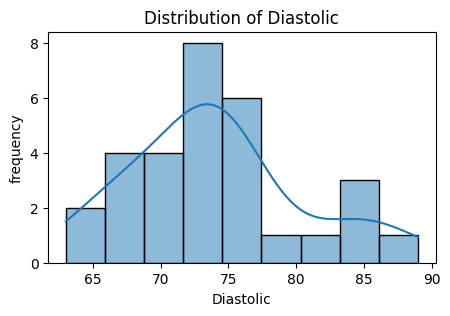

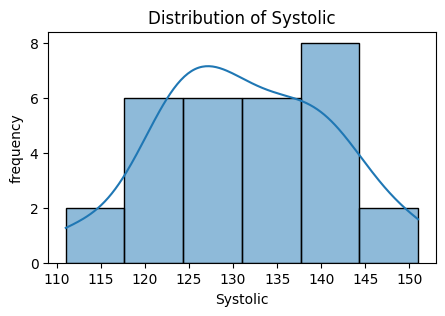

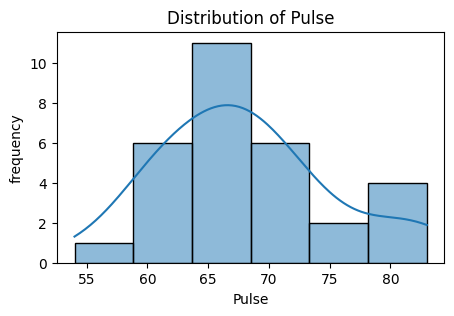

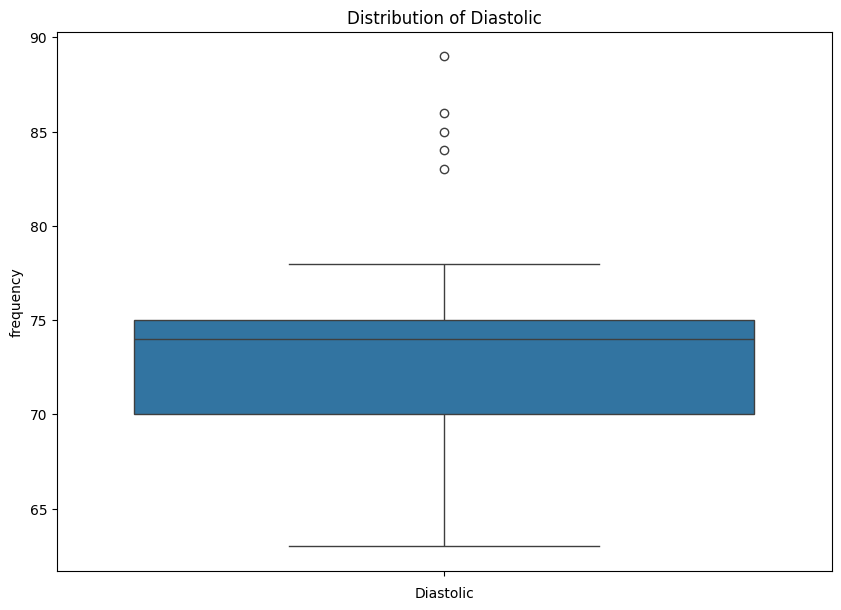

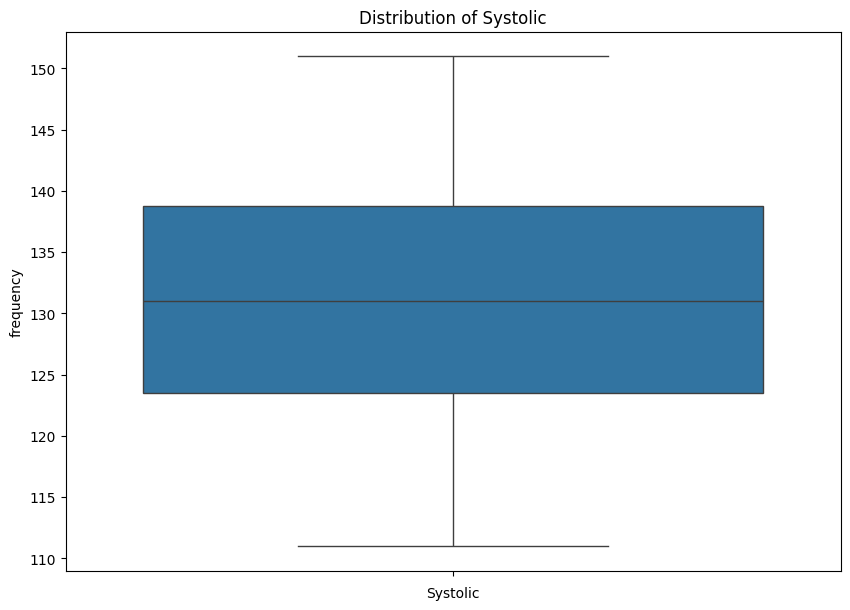

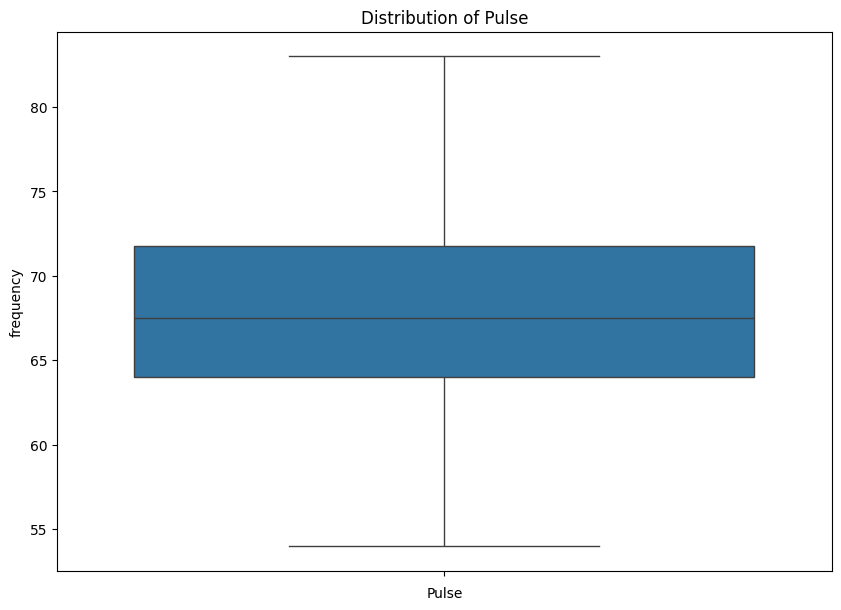

In [68]:
plot_Univariate_num(df_L, num_cols)

In [69]:
df_L

,day,date,time_of_day,Diastolic,Systolic,Pulse
0,1.0,1405/2/8,morning,89.0,149.0,65.0
1,1.0,1405/2/8,noon,74.0,140.0,83.0
2,1.0,1405/2/8,night,69.0,138.0,62.0
3,2.0,1405/2/9,morning,78.0,151.0,60.0
4,2.0,1405/2/9,noon,75.0,141.0,64.0
5,2.0,1405/2/9,night,75.0,137.0,69.0
6,3.0,1405/2/10,morning,83.0,127.0,64.0
7,3.0,1405/2/10,noon,66.0,113.0,67.0
8,3.0,1405/2/10,night,77.0,138.0,69.0
9,4.0,1405/2/11,morning,75.0,128.0,54.0


In [70]:
melted_list = [df_L['Pulse'] , df_L['Systolic'] , df_L['Diastolic']]
name = ['Pulse', 'Systolic', 'Diastolic']


for d, n in zip(melted_list,name):
    print('-'*24 , f'Average value for {n}', ''*25)
    print(df_L.groupby('time_of_day', observed=False )[n].mean())
    print('-'*50)




------------------------ Average value for Pulse 
time_of_day
morning    62.1
night      69.3
noon       72.6
Name: Pulse, dtype: float64
--------------------------------------------------
------------------------ Average value for Systolic 
time_of_day
morning    131.1
night      133.1
noon       129.9
Name: Systolic, dtype: float64
--------------------------------------------------
------------------------ Average value for Diastolic 
time_of_day
morning    76.9
night      75.2
noon       70.0
Name: Diastolic, dtype: float64
--------------------------------------------------


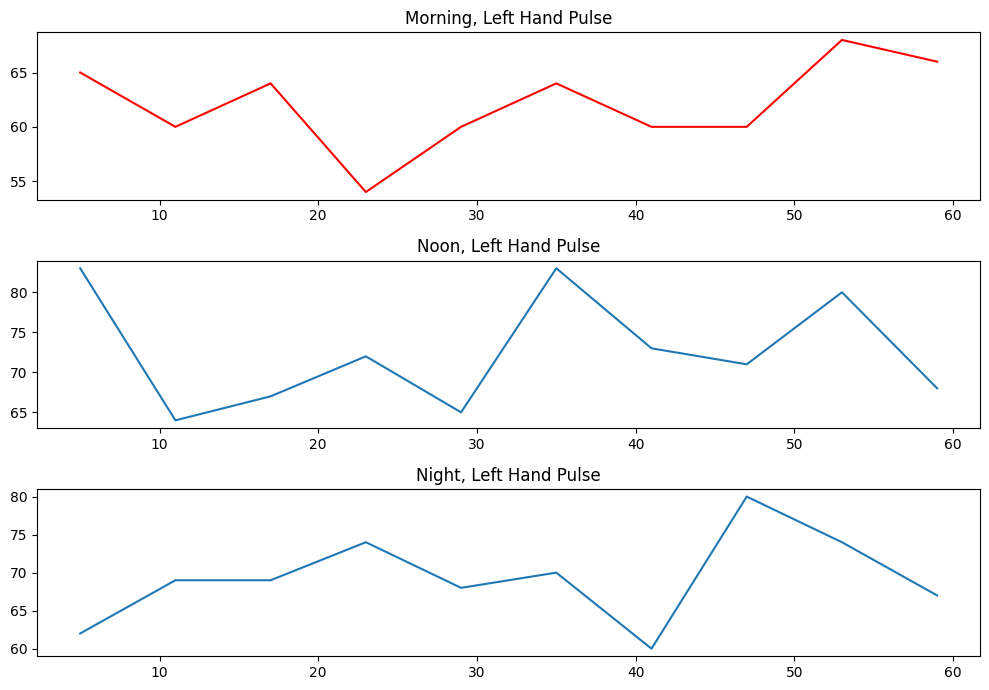

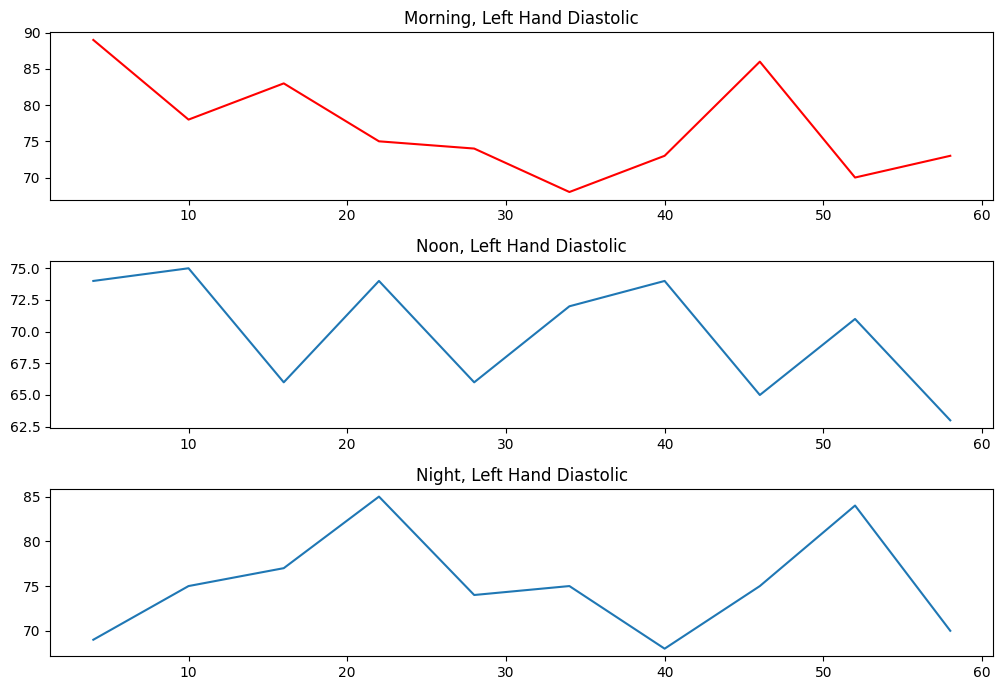

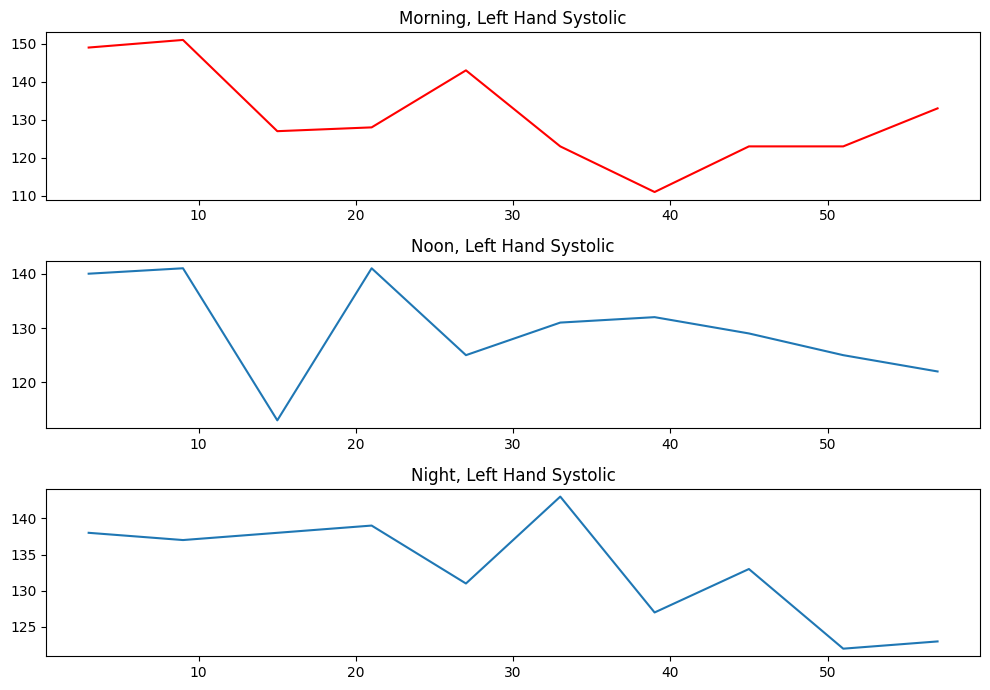

In [71]:
# Analysis of Left hand

datasets = [df_L_p , df_L_d , df_L_s]
names = ['Pulse' , 'Diastolic', 'Systolic']

Plot_L(datasets, names)

In [72]:
datasets = [
    (df_L_dt,df_R_dt),
    (df_L_st, df_R_st),
    (df_L_pt, df_R_pt)
]
names = ['Dystolic', 'Systolic', 'Pulse']

threshold = 0.05
for i,(l,r) in enumerate(datasets):
    name = names[i]
    result = mannwhitneyu(l['measurement'], r['measurement'])
    if result[1] < threshold:
        print(f'The Distribution of right and left {name} is not Identical And H_0 is rejected by {result[1]:.2f}')
    else:
        print(f'The Distribution of right and left {name} is Identical')

The Distribution of right and left Dystolic is not Identical And H_0 is rejected by 0.02
The Distribution of right and left Systolic is not Identical And H_0 is rejected by 0.01
The Distribution of right and left Pulse is Identical


- Pulse: the pulse if it is taken on the right or left hand would not differ
    - based on this I just choose the Left hand data in further analysis for the Pulse.
- Diastolic & Systolic: The Null hypothesis is Rejected and we do not have a identical distributions.
    - I think I should do separate analysis for Left and Right hand measures

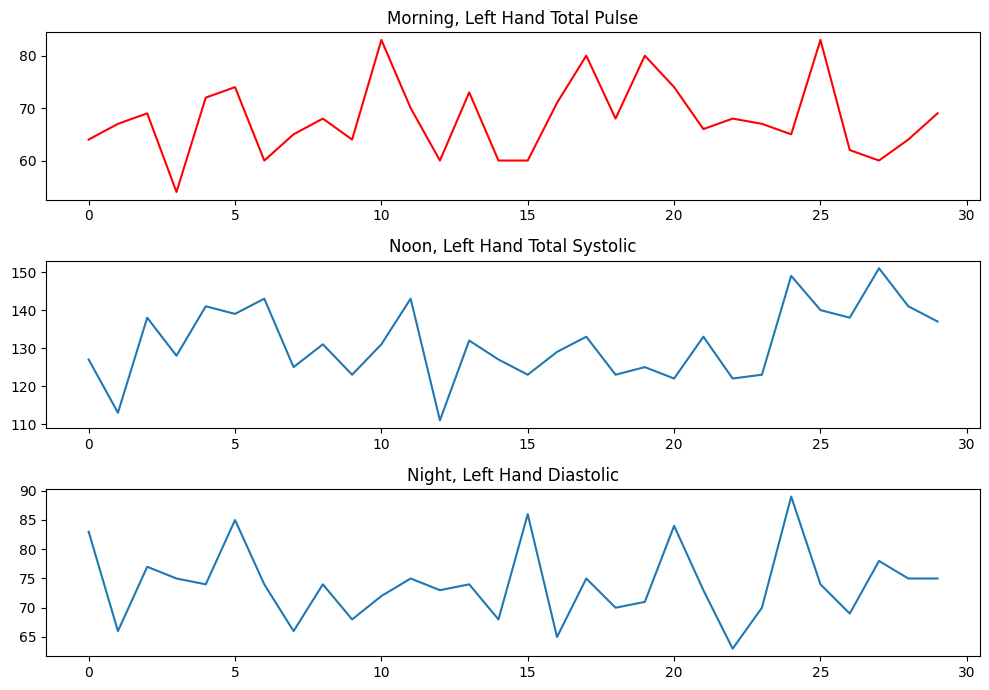

In [73]:
fig, ax = plt.subplots(3,1,figsize=(10,7))

ax[0].plot(df_L_pt['measurement'], color = 'red')
ax[0].set_title('Morning, Left Hand Total Pulse')

ax[1].plot(df_L_st['measurement'])
ax[1].set_title('Noon, Left Hand Total Systolic')

ax[2].plot(df_L_dt['measurement'])
ax[2].set_title('Night, Left Hand Diastolic')
plt.tight_layout()
plt.show()

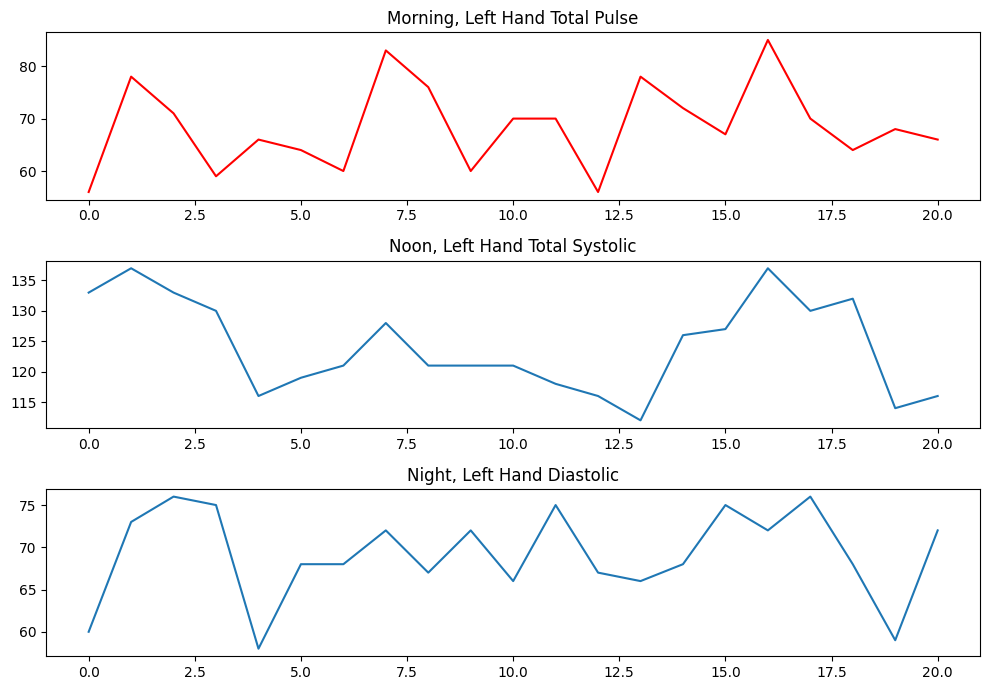

In [74]:
fig, ax = plt.subplots(3,1,figsize=(10,7))

ax[0].plot(df_R_pt['measurement'], color = 'red')
ax[0].set_title('Morning, Left Hand Total Pulse')

ax[1].plot(df_R_st['measurement'])
ax[1].set_title('Noon, Left Hand Total Systolic')

ax[2].plot(df_R_dt['measurement'])
ax[2].set_title('Night, Left Hand Diastolic')
plt.tight_layout()
plt.show()

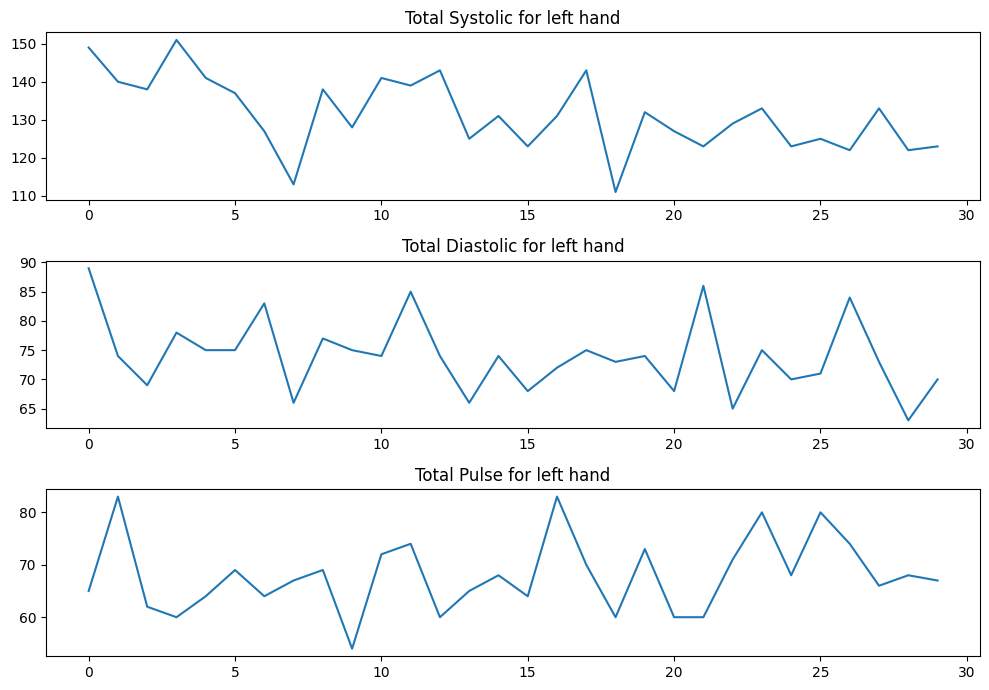

In [75]:

fig, ax = plt.subplots(3,1,figsize=(10,7))

ax[0].plot(df_L['Systolic'])
ax[0].set_title('Total Systolic for left hand')

ax[1].plot(df_L['Diastolic'])
ax[1].set_title('Total Diastolic for left hand')

ax[2].plot(df_L['Pulse'])
ax[2].set_title('Total Pulse for left hand')

plt.tight_layout()
plt.show()


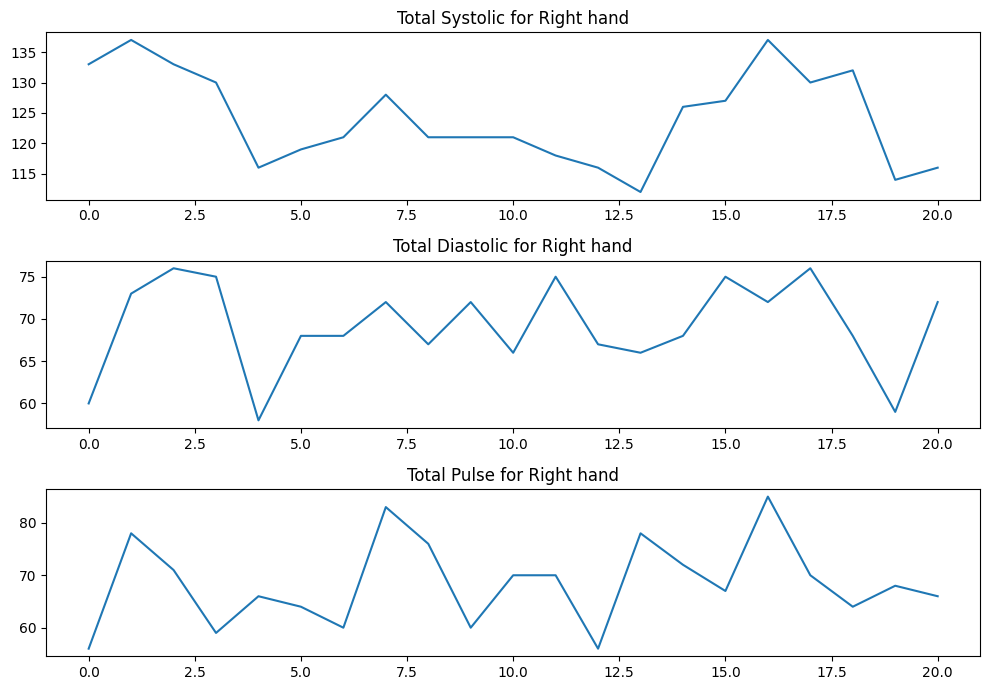

In [76]:

fig, ax = plt.subplots(3,1,figsize=(10,7))

ax[0].plot(df_R['Systolic'])
ax[0].set_title('Total Systolic for Right hand')

ax[1].plot(df_R['Diastolic'])
ax[1].set_title('Total Diastolic for Right hand')

ax[2].plot(df_R['Pulse'])
ax[2].set_title('Total Pulse for Right hand')

plt.tight_layout()
plt.show()

In [77]:
print(f'frequency table for Time of the day')
print(df_L['time_of_day'].value_counts())
print(df_L['time_of_day'].value_counts(normalize=True))
print('-'*50)

frequency table for Time of the day
time_of_day
morning    10
noon       10
night      10
Name: count, dtype: int64
time_of_day
morning    0.333333
noon       0.333333
night      0.333333
Name: proportion, dtype: float64
--------------------------------------------------


- Insights: 
    - Manwhitney test proved that the Pulse measurements that were taken from left and right hand is not different, and I choosed to use the Left hand measurements.

## Bi-variate Analysis

### Numerical vs Numerical

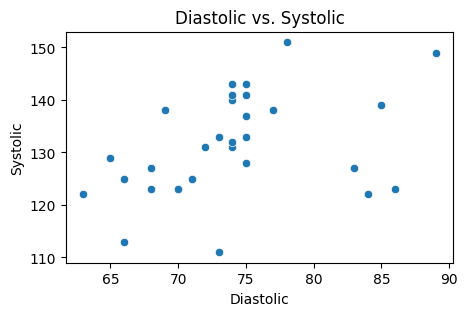

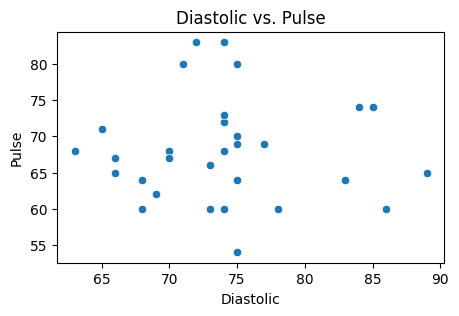

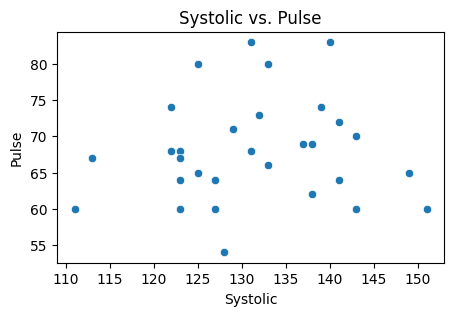

In [78]:
num_pairs = [
    ('Diastolic', 'Systolic'),
    ('Diastolic', 'Pulse'),
    ('Systolic' , 'Pulse')
]

for x,y in num_pairs:
   plt.figure(figsize=(5,3)) 
   sns.scatterplot(x = df_L[x] , y=df_L[y])
   plt.title(f'{x} vs. {y}')
   plt.xlabel(x)
   plt.ylabel(y)
   plt.show()

- insights:
    - The only noticable pattern between variables is between Diastolic & Systolic
    - there is no relationship between Systolic or Diastolic to pulse
    - I will investigate this further with pearson's correlation ceoficient

,Diastolic,Systolic,Pulse
Diastolic,1.000000,0.394424,-0.021162
Systolic,0.394424,1.000000,0.074529
Pulse,-0.021162,0.074529,1.000000


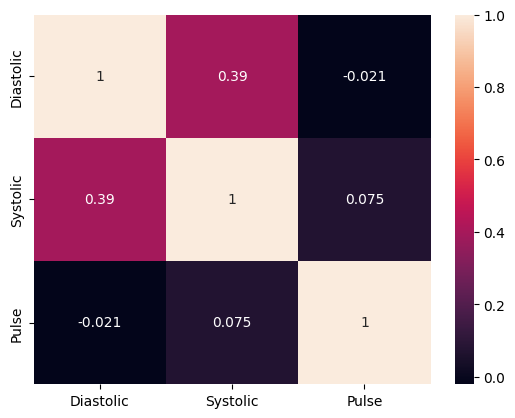

In [79]:
cor = df_L[num_cols].corr()
sns.heatmap(cor, annot=True)
cor

In [81]:
for col in num_cols:
    if col != 'Diastolic':
        r, p = pearsonr(df_L[col] ,df_L['Diastolic'])
        print(f'for {col} vs Diastolic the r is {r:.3f} and p is {p:.3f}')

for Systolic vs Diastolic the r is 0.394 and p is 0.031
for Pulse vs Diastolic the r is -0.021 and p is 0.912


### Numerical Vs Categorical
- we don't have very good and tangible categorical data
- maybe I should add something

## MultiVariate Analysis
- do clustermap
- pairplots

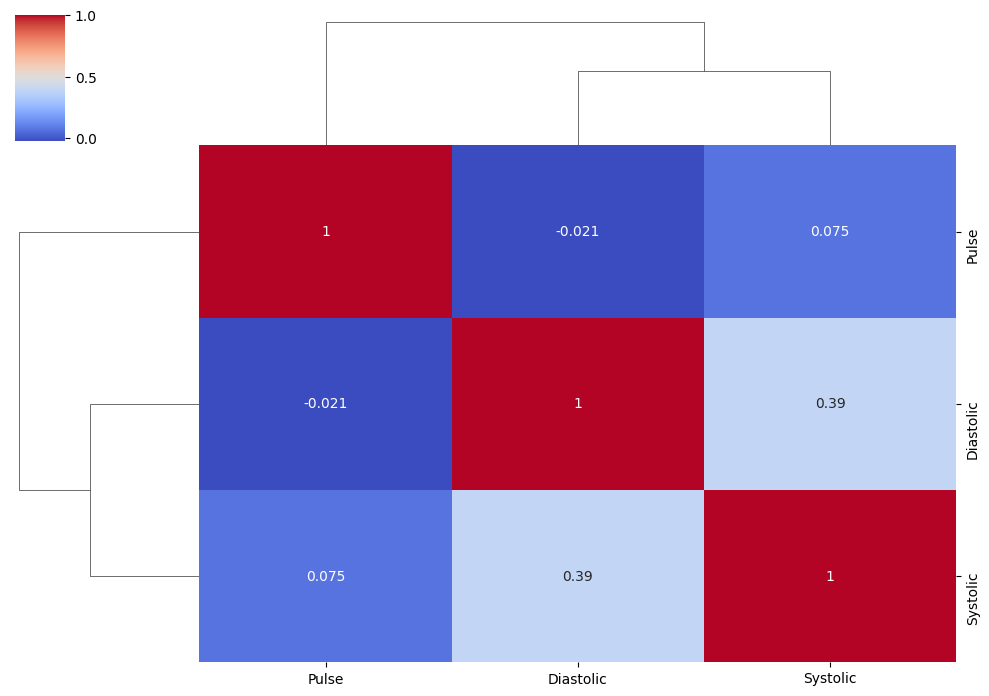

In [82]:
df_num = df_L[num_cols]
sns.clustermap(df_num.corr(), annot=True, cmap='coolwarm', figsize=(10,7))

## Outlier Detection
- IQR method
- Z_score method
- BoxPlot !DONE

### IQR Method:
- I use the IQR_bounds from the `Utils` that I've Built

In [83]:
iqr_bounds(df_L['Systolic'])

(np.float64(100.625), np.float64(161.625), np.float64(15.25))

In [86]:
for col in num_cols:
    col_clean = df_num[col].dropna()
    lower, upper , iqr = iqr_bounds(col_clean)
    outlier_mask = (col_clean > upper) | (col_clean < lower)
    num_outlier = outlier_mask.sum()
    total = col_clean.shape[0]
    
    print(f'IQR analysis for {col}')
    print(f'lower bound {lower:.2f}')
    print(f'Upper bound {upper:.2f}')
    print(f'IQR: {iqr}')
    print(f'we have {num_outlier} outliers out of {total}')
    print('-'*50)

IQR analysis for Diastolic
lower bound 62.50
Upper bound 82.50
IQR: 5.0
we have 5 outliers out of 30
--------------------------------------------------
IQR analysis for Systolic
lower bound 100.62
Upper bound 161.62
IQR: 15.25
we have 0 outliers out of 30
--------------------------------------------------
IQR analysis for Pulse
lower bound 52.38
Upper bound 83.38
IQR: 7.75
we have 0 outliers out of 30
--------------------------------------------------


### Z-Score method:

In [89]:
z_threshold = 3
for col in num_cols:
    col_clean = df_num[col].dropna()
    mean = col_clean.mean()
    std = col_clean.std()
    z_score = (col_clean - mean) / std
    outlier_mask = np.abs(z_score) > z_threshold
    num_outlier = outlier_mask.sum()
    total = col_clean.shape[0] 

    print(f'IQR analysis for {col}')
    print(f'mean: {mean:.2f} , std: {std:.2f}')
    print(f'threshold: {z_threshold}')
    print(f'outlier {num_outlier} in {total}')
    print('-'*50)

IQR analysis for Diastolic
mean: 74.03 , std: 6.37
threshold: 3
outlier 0 in 30
--------------------------------------------------
IQR analysis for Systolic
mean: 131.37 , std: 9.75
threshold: 3
outlier 0 in 30
--------------------------------------------------
IQR analysis for Pulse
mean: 68.00 , std: 7.17
threshold: 3
outlier 0 in 30
--------------------------------------------------


- Outlier Detection
    - I have 5 outliers in Diastolic from IQR method
    - no outliers from Z-Score